---
title: "Bayesian Optimization with TabPFN Extensions"
description: "Use TabPFN as a Bayesian optimization surrogate via tabpfn-extensions and compare it against random search on Hartmann-6."
cookbookTags:
  - extension
  - optimization
authors:
  - name: Klemens Flöge
    linkedin: https://www.linkedin.com/in/klemens-fl%C3%B6ge/
  - name: Tuana Çelik
    linkedin: https://www.linkedin.com/in/tuanacelik/
    twitter: https://x.com/tuanacelik
---

*Use TabPFN as the surrogate model inside a Bayesian optimization loop.*

This cookbook turns the `tabpfn-extensions` Bayesian optimization example into a step-by-step notebook. We optimize the 6D Hartmann benchmark, compare TabPFN-driven search against random search under the same evaluation budget, and show how `propose_next_point()` uses the predictive distribution from TabPFN to compute Expected Improvement (EI).

Relevant resources:

- [`tabpfn-extensions` repository](https://github.com/PriorLabs/tabpfn-extensions)
- [Bayesian optimization example script in `tabpfn-extensions`](https://github.com/PriorLabs/tabpfn-extensions/blob/main/examples/bayesian_optimization/bayesian_optimization.py)
- [`PFNs4BO` paper / reference implementation](https://github.com/automl/PFNs4BO)
- [TabPFN repo](https://github.com/PriorLabs/TabPFN)

## Setup

*Install the full TabPFN package plus the Bayesian optimization extras from `tabpfn-extensions`.*

This example uses the local PyTorch-backed TabPFN implementation because the optimizer refines candidates with gradients (`differentiable_input=True`).

In [35]:
!pip install -q -U "tabpfn-extensions[bayesian-optimization]" "tabpfn>=8.1.0" "tqdm>=4.63.0,<=4.67.3" matplotlib

*TabPFN as the surrogate, BoTorch for the benchmark objective, and Matplotlib for a quick comparison plot.*

In [36]:
import matplotlib.pyplot as plt
import torch
from botorch.test_functions import Hartmann
from tqdm.auto import trange

from tabpfn import TabPFNRegressor
from tabpfn_extensions.bayesian_optimization import propose_next_point

## The Optimization Problem

Hartmann-6 is a classic six-dimensional benchmark on `[0, 1]^6` where random search is weak.

The TabPFN surrogate predicts a **full bar distribution** over the objective value. `propose_next_point()` uses that predictive distribution to compute Expected Improvement, then refines the most promising candidates with gradient ascent on the acquisition function itself.

In [37]:
N_INIT = 10
N_BO_STEPS = 25
N_CANDIDATES = 512
TOP_K = 4
N_REFINE_STEPS = 8
REFINE_LR = 0.05

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print(f"Device: {DEVICE}")

# EI maximizes the objective, so we negate Hartmann to turn its optimum positive.
objective = Hartmann(dim=6, negate=True).to(DEVICE)
print(f"Objective optimum: {objective.optimal_value:.4f}")

Device: cpu
Objective optimum: 3.3224


## Build the TabPFN Surrogate

*The critical switch is `differentiable_input=True`.*

That flag keeps gradients flowing from the acquisition value back into the candidate coordinates during refinement. We use a single estimator to stay close to the upstream example and keep runtime short on CPU.

In [38]:
reg = TabPFNRegressor(
    n_estimators=1,
    device=DEVICE,
    random_state=0,
    inference_precision=torch.float32,
    differentiable_input=True,
)

## Run Bayesian Optimization

*Seed with random points, then let TabPFN propose the next evaluation point.*

Each iteration fits TabPFN on all observed evaluations so far, screens a random candidate pool with Expected Improvement, and refines the top candidates by gradient ascent before returning the next point to evaluate.

In [ ]:
train_x = torch.rand(N_INIT, objective.dim, device=DEVICE)
train_y = objective(train_x)

best_history = [train_y.max().item()]

for step in trange(N_BO_STEPS, desc="BO steps"):
    next_x = propose_next_point(
        reg,
        train_x,
        train_y,
        n_candidates=N_CANDIDATES,
        top_k=TOP_K,
        n_refine_steps=N_REFINE_STEPS,
        refine_lr=REFINE_LR,
    )
    next_y = objective(next_x.unsqueeze(0))
    train_x = torch.cat([train_x, next_x.unsqueeze(0)])
    train_y = torch.cat([train_y, next_y])
    best_history.append(train_y.max().item())
    print(
        f"step {step + 1:2d}: evaluated f={next_y.item():7.4f} | "
        f"best so far f={train_y.max().item():7.4f}"
    )

print(f"\nBest found by TabPFN with Bayesian Optimization: {train_y.max().item():.4f}")
print(f"(optimum: {objective.optimal_value:.4f})")

## Compare Against Random Search

*Use the same total evaluation budget for a fair baseline.*

In [43]:
random_y = objective(torch.rand(N_INIT + N_BO_STEPS, objective.dim, device=DEVICE))
random_best = torch.cummax(random_y, dim=0).values.cpu()
bo_best = torch.tensor(best_history)

print(f"Best found by random search: {random_y.max().item():.4f}")
print(f"Best found by TabPFN:   {train_y.max().item():.4f}")
print(f"Optimum:                   {objective.optimal_value:.4f}")

Best found by random search: 1.2780
Best found by TabPFN:   3.0235
Optimum:                   3.3224


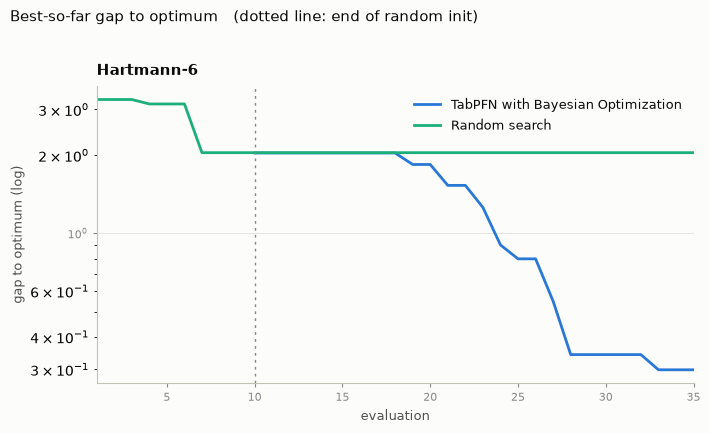

In [44]:
fig, ax = plt.subplots(figsize=(7.2, 4.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.set_yscale("log")

gap_floor = 1e-3
optimum = float(objective.optimal_value)
# Align BO history (starts after init) and random (full budget) onto evaluation counts.
bo_evals = list(range(N_INIT, N_INIT + len(bo_best)))
random_evals = list(range(1, len(random_best) + 1))
bo_gap = [max(optimum - float(v), gap_floor) for v in bo_best]
random_gap = [max(optimum - float(v), gap_floor) for v in random_best]

ax.plot(bo_evals, bo_gap, color="#2a78d6", lw=2, label="TabPFN with Bayesian Optimization")
ax.plot(random_evals, random_gap, color="#1baf7a", lw=2, label="Random search")
ax.axvline(N_INIT, color="#898781", lw=1, ls=(0, (2, 3)))

ax.set_title("Hartmann-6", fontsize=11, color="#0b0b0b", loc="left", fontweight="bold", pad=8)
ax.grid(visible=True, axis="y", color="#e1e0d9", linewidth=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#c3c2b7")
ax.tick_params(colors="#898781", labelsize=8, length=3)
ax.set_xlim(1, N_INIT + N_BO_STEPS)
ax.set_xlabel("evaluation", fontsize=9, color="#52514e")
ax.set_ylabel("gap to optimum (log)", fontsize=9, color="#52514e")
ax.legend(frameon=False, fontsize=9.5, labelcolor="#0b0b0b")

fig.suptitle(
    "Best-so-far gap to optimum   (dotted line: end of random init)",
    fontsize=11,
    color="#0b0b0b",
    x=0.02,
    ha="left",
    y=1.02,
)
fig.tight_layout()
plt.show()


## Takeaways

- `tabpfn-extensions` already provides the Bayesian Optimization loop primitive: `propose_next_point()`
- You need the **full** `tabpfn` package plus `tabpfn-extensions[bayesian_optimization]`; `tabpfn-client` is not enough here because the candidate refinement path needs differentiable local inference.
- On Hartmann-6, TabPFN with Bayesian Optimization should usually beat random search under the same evaluation budget.
- For more background, start with the upstream [example](https://github.com/PriorLabs/tabpfn-extensions/blob/main/examples/bayesian_optimization/bayesian_optimization.py) and the [`tabpfn-extensions` repo](https://github.com/PriorLabs/tabpfn-extensions).